# **K-Means** is an unsupervised machine learning algorithm used for clustering data into K distinct groups based on similarity.

It works by:

1.Choosing K cluster centers (centroids)

2.Assigning each data point to the nearest centroid

3.Updating centroids based on the mean of assigned points

4.Repeating until the clusters stabilize

The goal is to minimize the within-cluster variance (i.e., make points in the same cluster as similar as possible).

👉 In simple terms:
K-Means groups data into K clusters by placing similar points together around central points (centroids).

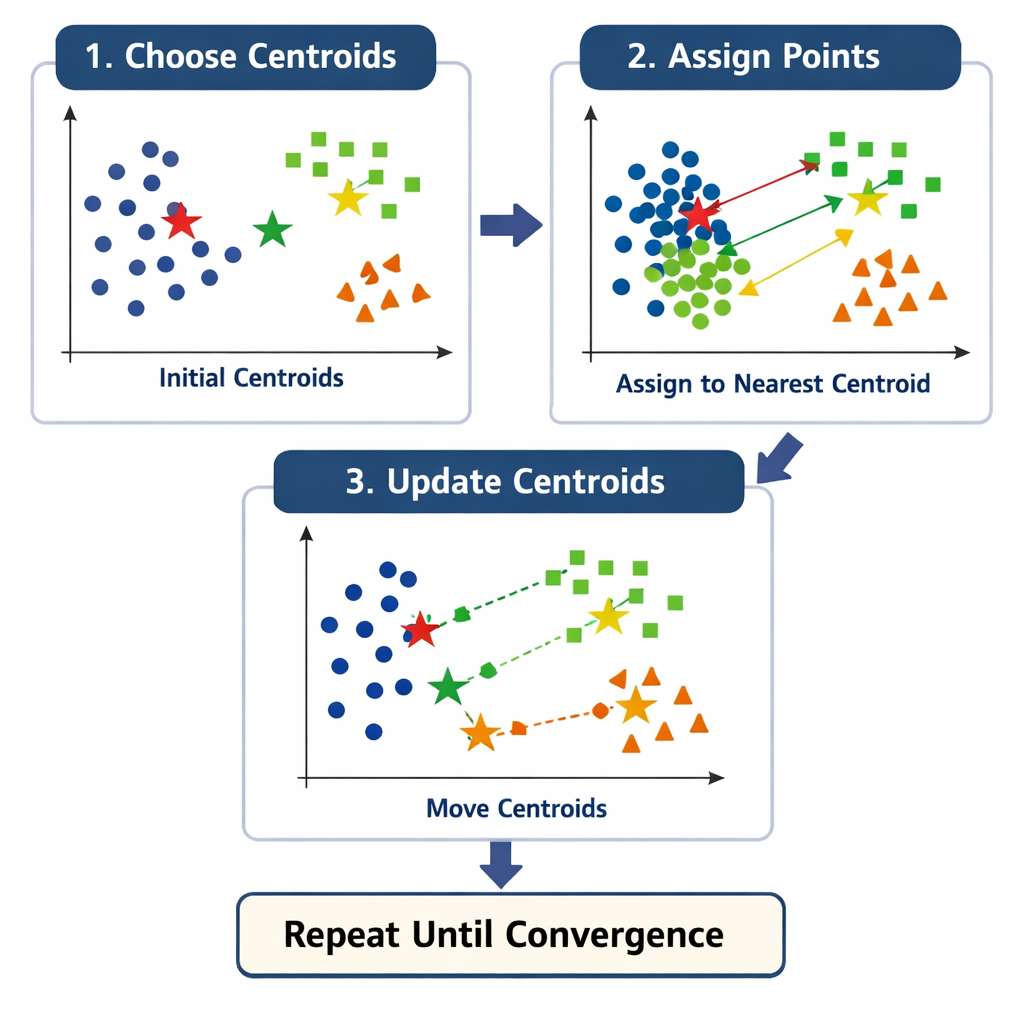

In [1]:
# Basic numerical / data libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix, classification_report

# Display settings for nicer tables/plots
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid", context="notebook")


In [2]:
# Load wine dataset from sklearn
wine = load_wine()

# Create a DataFrame for features
X = pd.DataFrame(wine.data, columns=wine.feature_names)

# Create a Series for the target (cultivar) for reference (not used in K-Means training)
y = pd.Series(wine.target, name="target")

# Combine features + target for exploration (optional)
df = X.copy()
df["target"] = y

# Show basic info
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Basic Data Exploration involves an initial assessment of the dataset to ensure it is suitable for clustering. This includes inspecting the dataset shape (number of rows and columns), checking the data types of each column, identifying any missing values, and reviewing statistical summaries of numerical features. These steps help confirm that all features are numeric an essential requirement for K-Means and determine whether any data cleaning or preprocessing is needed before applying the clustering algorithm.

In [3]:
# Shape of the dataset
print("Shape of the dataset (rows, columns):", df.shape)

# Data types and non-null counts
print("\nInfo:")
print(df.info())

# Check for missing values
print("\nMissing values per column:")
print(df.isna().sum())

# Descriptive statistics of features
print("\nStatistical summary of features:")
df.describe().T


Shape of the dataset (rows, columns): (178, 14)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline  

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


Feature Names and Target Distribution involves understanding the dataset structure and class composition before clustering. Although K-Means is an unsupervised algorithm and does not use labels during training, the Wine dataset provides true cultivar labels that can later be used for evaluation. In this step, we programmatically list all feature names to understand the input variables and examine the distribution of samples across each cultivar class in the target column. This helps assess class balance and provides a reference for comparing how well the clusters align with the actual wine categories.

In [4]:
# Print feature names from the sklearn dataset
print("Feature names:", wine.feature_names)

# Target names (cultivar classes)
print("Target names (cultivars):", wine.target_names)

# Distribution of target classes
print("\nTarget class distribution:")
print(df["target"].value_counts().sort_index())


Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target names (cultivars): ['class_0' 'class_1' 'class_2']

Target class distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64


In [5]:
# Exploratory Data Analysis (EDA)
# Plot histograms
# Create a pairplot
# Examine a correlation matrix

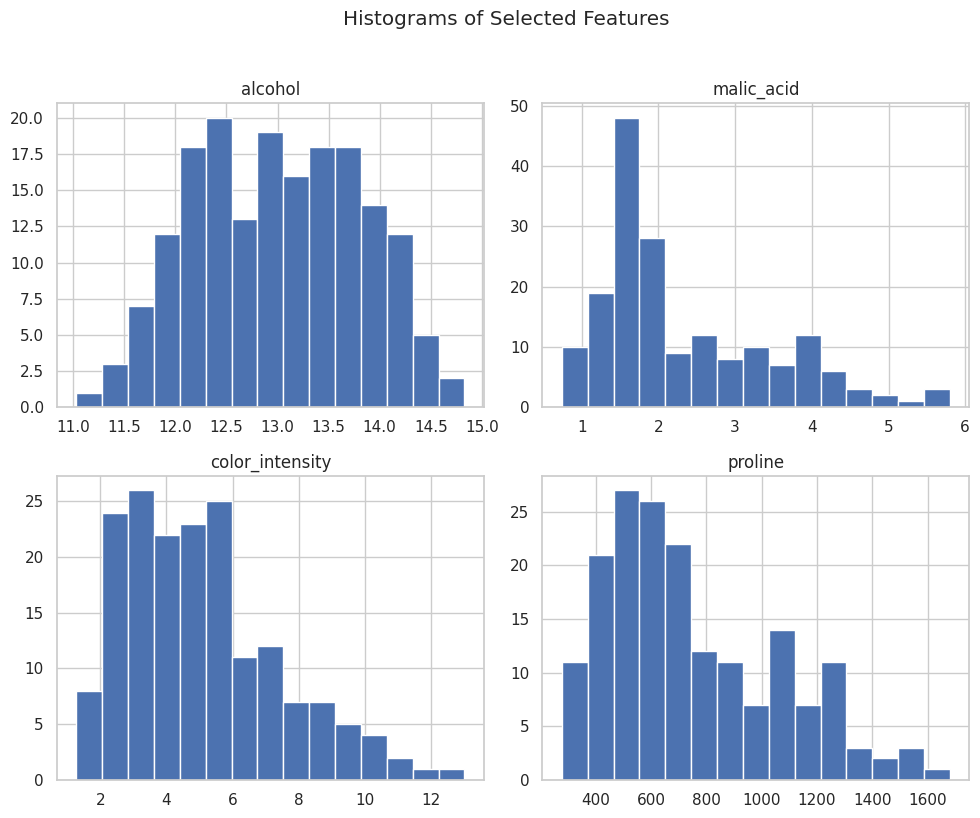

In [6]:
selected_features = ["alcohol", "malic_acid", "color_intensity", "proline"]

# Histograms
df[selected_features].hist(bins=15, figsize=(10, 8))
plt.suptitle("Histograms of Selected Features", y=1.02)
plt.tight_layout()
plt.show()

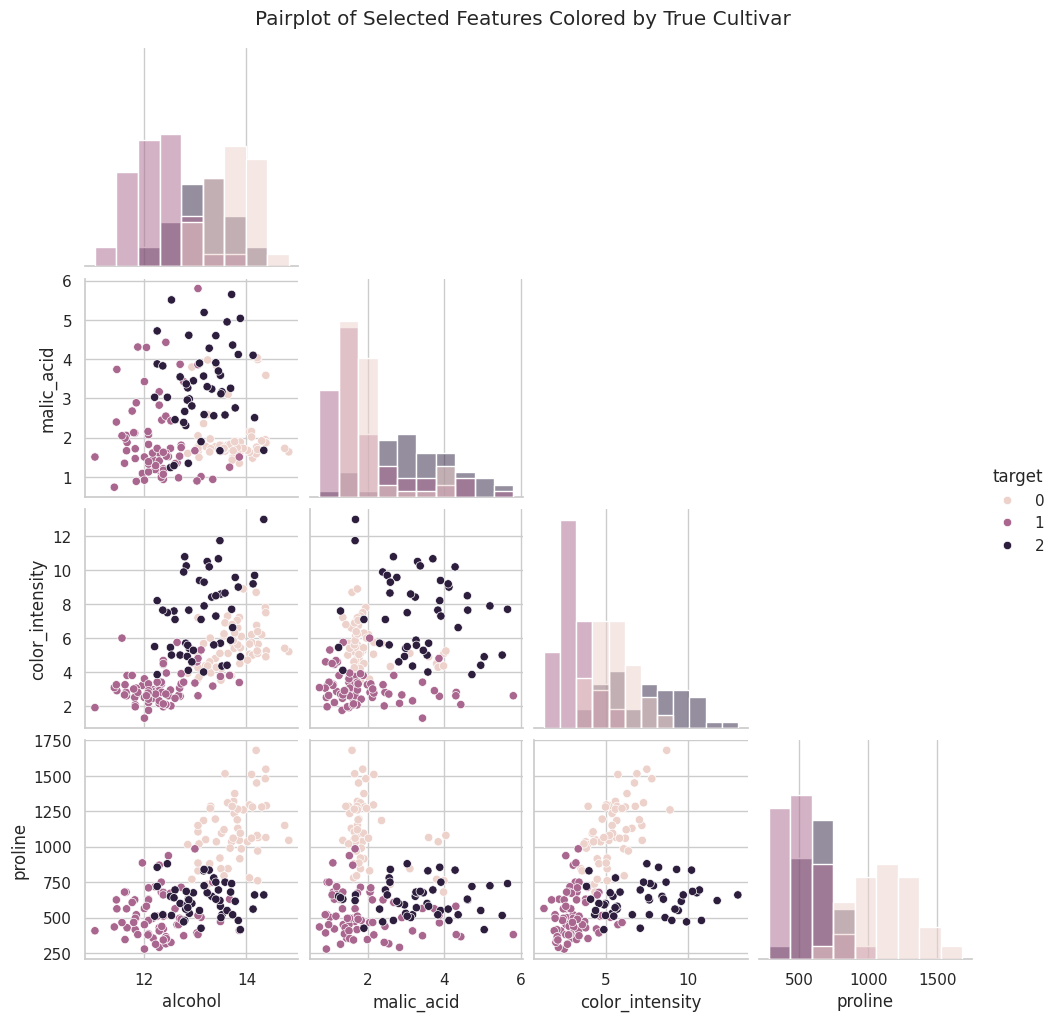

In [7]:
sns.pairplot(
    df[selected_features + ["target"]],
    hue="target",
    diag_kind="hist",
    corner=True
)
plt.suptitle("Pairplot of Selected Features Colored by True Cultivar", y=1.02)
plt.show()

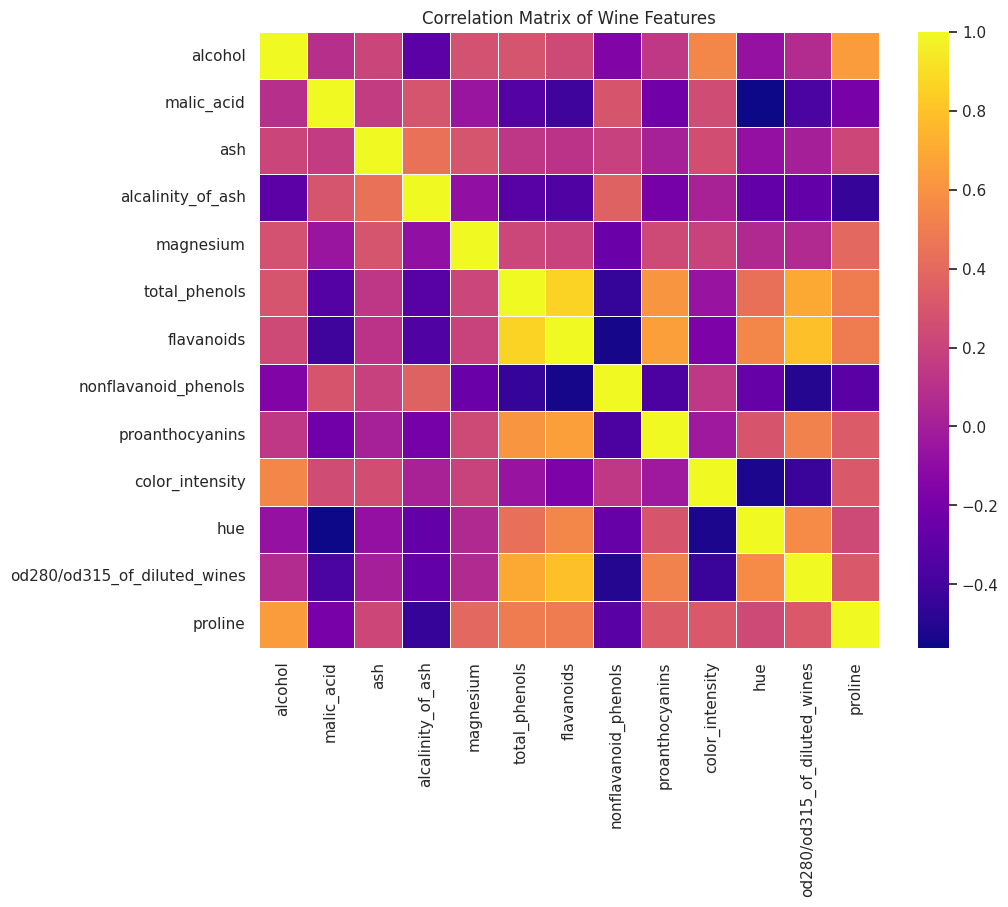

In [8]:
plt.figure(figsize=(10, 8))
corr = X.corr()
sns.heatmap(corr, annot=False, cmap="plasma", linewidths=0.5)
plt.title("Correlation Matrix of Wine Features")
plt.show()

Preprocessing through feature scaling is essential for K-Means since it relies on distance metrics like Euclidean distance. If features have different scales, those with larger values can dominate the clustering process. To address this, StandardScaler is applied to standardize each feature to have a mean of 0 and a standard deviation of 1. The clustering is then performed on the scaled data (X_scaled), while the original feature set (X) is retained for reference and interpretation.

In [9]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on features and transform
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for convenience
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [10]:
# PCA for 2D Visualization
# Initialize PCA to get 2 main components
pca = PCA(n_components=2, random_state=42)

# Fit PCA on scaled features and transform
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for PCA components
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["target"] = y

pca_df.head()


,PC1,PC2,target
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


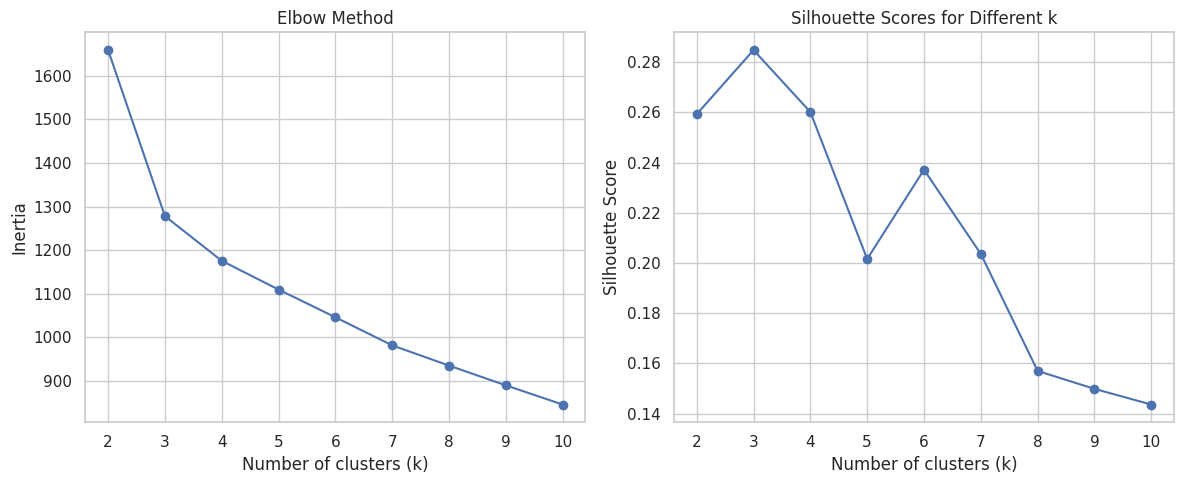

[(2, 1658.758852429096, np.float64(0.2593169555318255)),
 (3, 1277.928488844643, np.float64(0.2848589191898987)),
 (4, 1175.4283331033473, np.float64(0.26017035223704527)),
 (5, 1109.5127392938246, np.float64(0.20161908294074093)),
 (6, 1046.002333214364, np.float64(0.23716725754166543)),
 (7, 981.5952326111659, np.float64(0.2036275812271175)),
 (8, 935.2012114738552, np.float64(0.1570139556393107)),
 (9, 889.8929111933174, np.float64(0.14988199178183517)),
 (10, 845.8952366525515, np.float64(0.1436384079124149))]

In [11]:
# Selecting the Number of Clusters
inertias = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)

    # Inertia (sum of squared distances to centroids)
    inertias.append(kmeans.inertia_)

    # Silhouette score
    labels = kmeans.labels_
    sil_score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil_score)

# Plot inertia (Elbow)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

# Plot silhouette scores
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different k")

plt.tight_layout()
plt.show()

list(zip(k_values, inertias, silhouette_scores))

In [12]:
# Final K-Means Model (K = 3)
# Fit KMeans with K=3
k_optimal = 3
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

# Cluster labels
cluster_labels = kmeans_final.labels_

# Add to DataFrame
df["cluster"] = cluster_labels

# Show first few rows with cluster assignments
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,cluster
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,2
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,2
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,2
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,2
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,2


In [13]:
# Centroids in scaled feature space
centroids_scaled = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=X.columns
)

print("Cluster centroids in scaled feature space:")
centroids_scaled

Cluster centroids in scaled feature space:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,-0.926072,-0.394042,-0.494517,0.170602,-0.491712,-0.075983,0.020813,-0.033534,0.058266,-0.901914,0.461804,0.270764,-0.753846
1,0.164907,0.871547,0.186898,0.524367,-0.075473,-0.979330,-1.215248,0.726064,-0.779706,0.941539,-1.164789,-1.292412,-0.407088
2,0.835232,-0.303810,0.364706,-0.610191,0.577587,0.885237,0.977820,-0.562090,0.580287,0.171063,0.473984,0.779247,1.125185


Evaluating clusters using true labels provides a reference to assess how well K-Means has captured the underlying structure of the Wine dataset. Although K-Means is unsupervised and does not use labels during training, we can compare the cluster assignments with the true cultivar labels using metrics like the Adjusted Rand Index (ARI), where a value close to 1 indicates strong agreement and values near 0 indicate random clustering. Additionally, a confusion matrix is used to visually compare true labels with cluster labels. Since K-Means assigns arbitrary numeric cluster IDs, interpretation focuses on whether each true class predominantly maps to a single cluster, indicating meaningful alignment.

Adjusted Rand Index (ARI): 0.8974949815093207

Confusion Matrix (rows=true class, columns=cluster):
 [[ 0  0 59]
 [65  3  3]
 [ 0 48  0]]


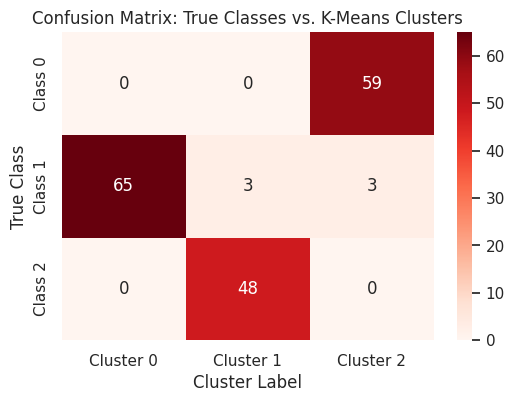

In [15]:
# Adjusted Rand Index
ari = adjusted_rand_score(y, df["cluster"])
print("Adjusted Rand Index (ARI):", ari)

# Confusion Matrix
cm = confusion_matrix(y, df["cluster"])
print("\nConfusion Matrix (rows=true class, columns=cluster):\n", cm)

# Nice heatmap of confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=[f"Cluster {i}" for i in range(k_optimal)],
            yticklabels=[f"Class {i}" for i in sorted(y.unique())])
plt.xlabel("Cluster Label")
plt.ylabel("True Class")
plt.title("Confusion Matrix: True Classes vs. K-Means Clusters")
plt.show()


To better interpret the clustering results, the high-dimensional data is projected into a 2D space using PCA and visualized using the first two principal components (PC1 vs. PC2). In this space, both the true cultivar labels and the K-Means cluster assignments are plotted for comparison. This visualization helps assess how well K-Means captures the natural separation between wine classes and allows us to observe whether clusters are clearly separated or exhibit overlap in the feature space.

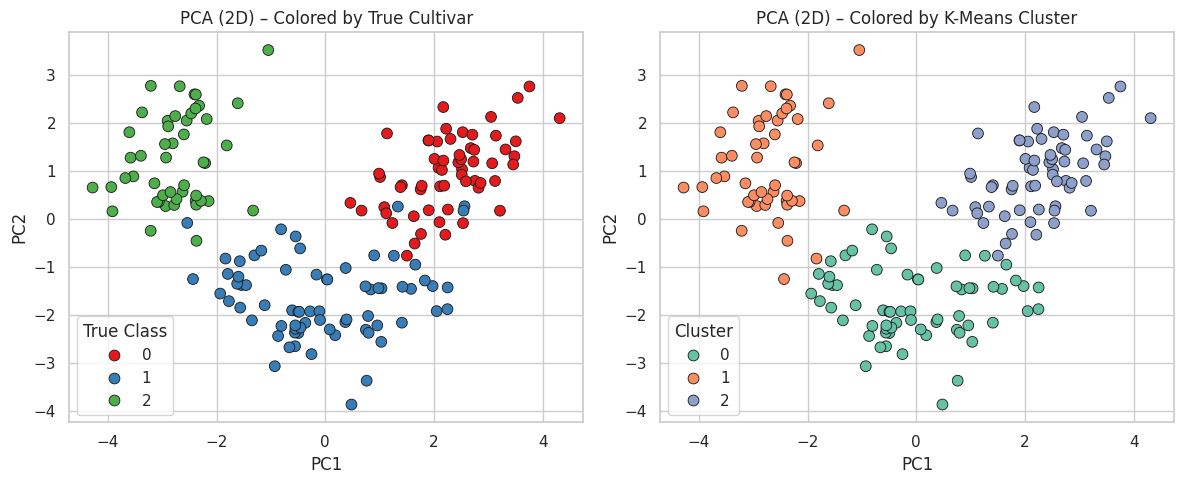

In [16]:
# Add cluster labels to PCA DataFrame
pca_df["cluster"] = cluster_labels

plt.figure(figsize=(12, 5))

# Left: True labels
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="target",
    palette="Set1",
    s=60,
    edgecolor="k"
)
plt.title("PCA (2D) – Colored by True Cultivar")
plt.legend(title="True Class")

# Right: Cluster labels
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="cluster",
    palette="Set2",
    s=60,
    edgecolor="k"
)
plt.title("PCA (2D) – Colored by K-Means Cluster")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

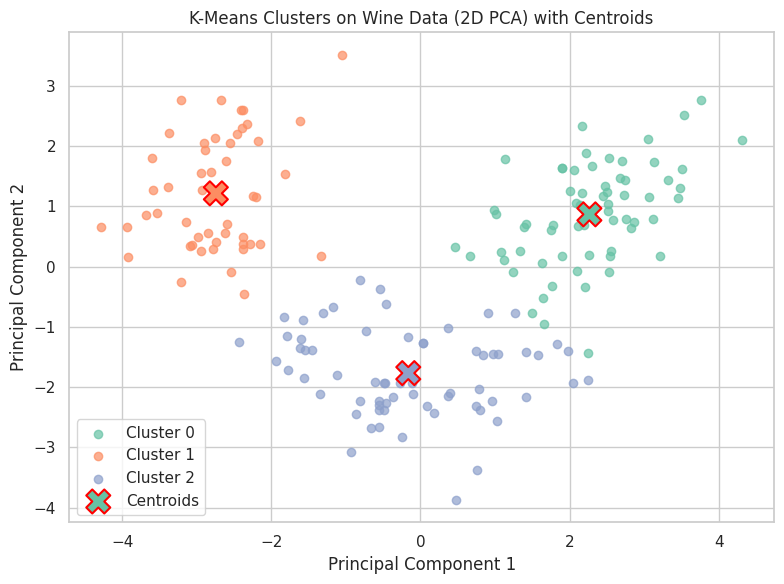

In [18]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Use same categorical palette as first Seaborn plot
palette = sns.color_palette("Set2", n_colors=3)

# PCA to 2 dimensions
pca_2d = PCA(n_components=2, random_state=42)
X_pca2 = pca_2d.fit_transform(X_scaled)

# KMeans on PCA-reduced data
kmeans_2d = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_2d = kmeans_2d.fit_predict(X_pca2)

# Centroids
centroids_2d = kmeans_2d.cluster_centers_

plt.figure(figsize=(8, 6))

# Plot each cluster with the same colors as Set2
for i in range(3):
    plt.scatter(
        X_pca2[clusters_2d == i, 0],
        X_pca2[clusters_2d == i, 1],
        color=palette[i],
        label=f"Cluster {i}",
        alpha=0.7
    )

# Plot centroids using matching colors
plt.scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    c=palette,
    marker='X',
    s=300,
    edgecolors='red',
    linewidths=1.5,
    label="Centroids"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters on Wine Data (2D PCA) with Centroids")
plt.legend()
plt.tight_layout()
plt.show()


Conclusion

K-Means clustering, with
k=3, successfully captured the underlying structure of the Wine dataset, producing clusters that show meaningful alignment with the true cultivars. The positive Adjusted Rand Index and confusion matrix confirm that most samples from each class are grouped into dominant clusters, although some overlap exists due to similarities in chemical features. PCA visualization further demonstrates well-separated centroids and compact clusters, supporting the effectiveness of the model. Overall, the results highlight that K-Means can uncover significant patterns in high-dimensional data, while also reflecting inherent overlap that limits perfect separation.